# Appliance Energy Use — Time Series Forecasting Case Study

This notebook works through a short forecasting study on household appliance
energy use. It goes from raw data all the way to a comparison of several
models, following the structure of the coursework brief.

The rough plan:

1. Load and tidy the data (10-minute readings → hourly).
2. Look at it and test whether it's stationary.
3. Set up a single train/test split that every model shares.
4. Try some simple benchmark forecasts.
5. Fit a SARIMAX model.
6. Add engineered features and fit a gradient-boosting / random-forest model.
7. Run a time-series foundation model (Chronos) and compare it with the simpler models.
8. Put all the results side by side.

A note to self before running: keep the same test window for *every* model,
otherwise the final comparison table isn't really comparing like with like.
That mistake is easy to make and annoying to spot later.


## 0. Setup

Install the couple of libraries Colab doesn't already have, then import
everything. `xgboost` is usually preinstalled on Colab; `chronos-forecasting`
is only needed if you actually run the foundation-model section at the end.

In [1]:
# Core packages plus the time-series foundation model used in Part 7.
# Run this cell first in Colab.
!pip install -q statsmodels xgboost chronos-forecasting torch >/dev/null 2>&1

import warnings
warnings.filterwarnings("ignore")   # statsmodels is chatty during grid search

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42   # keep results reproducible run-to-run

## 1. Load and prepare the data

The dataset is the UCI *Appliances Energy Prediction* set (Candanedo et al.,
2017). It's sampled every 10 minutes; we bin it up to hourly, which is a more
sensible resolution for a 24-hour-ahead forecast and cuts a lot of noise.

I'm pulling it from a GitHub mirror so the notebook runs without any manual
download. If that link ever dies, grab `energydata_complete.csv` from the UCI
page and upload it to the Colab session instead.

In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/"
    "energydata_complete.csv"
)

raw = pd.read_csv(DATA_URL)
raw["date"] = pd.to_datetime(raw["date"])
raw = raw.set_index("date").sort_index()

print("Raw shape:", raw.shape)
print("From", raw.index.min(), "to", raw.index.max())
raw.head()


Raw shape: (19735, 28)
From 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.60,19.20,44.79,19.79,44.73,19.00,45.57,...,17.03,45.53,6.60,733.50,92.00,7.00,63.00,5.30,13.28,13.28
2016-01-11 17:10:00,60,30,19.89,46.69,19.20,44.72,19.79,44.79,19.00,45.99,...,17.07,45.56,6.48,733.60,92.00,6.67,59.17,5.20,18.61,18.61
2016-01-11 17:20:00,50,30,19.89,46.30,19.20,44.63,19.79,44.93,18.93,45.89,...,17.00,45.50,6.37,733.70,92.00,6.33,55.33,5.10,28.64,28.64
2016-01-11 17:30:00,50,40,19.89,46.07,19.20,44.59,19.79,45.00,18.89,45.72,...,17.00,45.40,6.25,733.80,92.00,6.00,51.50,5.00,45.41,45.41
2016-01-11 17:40:00,60,40,19.89,46.33,19.20,44.53,19.79,45.00,18.89,45.53,...,17.00,45.40,6.13,733.90,92.00,5.67,47.67,4.90,10.08,10.08


### Missing values and gaps

Two different things to check here. `isna()` catches blank cells, but it won't
notice if an entire 10-minute row is simply *absent* from the file — so I also
rebuild the full expected timestamp range and see what's missing from it.

In [3]:
print("Blank cells per column (showing only non-zero):")
print(raw.isna().sum()[raw.isna().sum() > 0])

expected = pd.date_range(raw.index.min(), raw.index.max(), freq="10min")
gaps = expected.difference(raw.index)
print(f"\nMissing 10-minute rows (gaps in the index): {len(gaps)}")

Blank cells per column (showing only non-zero):
Series([], dtype: int64)

Missing 10-minute rows (gaps in the index): 0


Clean dataset — no blanks, no gaps — so no imputation is needed. That's
worth a sentence in the report, since it means later modelling choices aren't
being muddied by gap-filling artefacts.

### Resample to hourly

I'm taking the hourly **mean**. For the weather/sensor columns that's the
natural choice. For `Appliances` you could argue for a sum (total Wh per hour)
instead — either is defensible as long as you're consistent and say which you
picked. Mean keeps every column on the same footing, so that's what I use.

In [4]:
hourly = raw.resample("1h").mean()
print("Hourly shape:", hourly.shape)

# rv1/rv2 are random noise columns baked into this dataset - drop them early
hourly = hourly.drop(columns=["rv1", "rv2"], errors="ignore")

hourly[["Appliances"]].head()

Hourly shape: (3290, 28)


,Appliances
date,
2016-01-11 17:00:00,55.00
2016-01-11 18:00:00,176.67
2016-01-11 19:00:00,173.33
2016-01-11 20:00:00,125.00
2016-01-11 21:00:00,103.33


### First look at the target

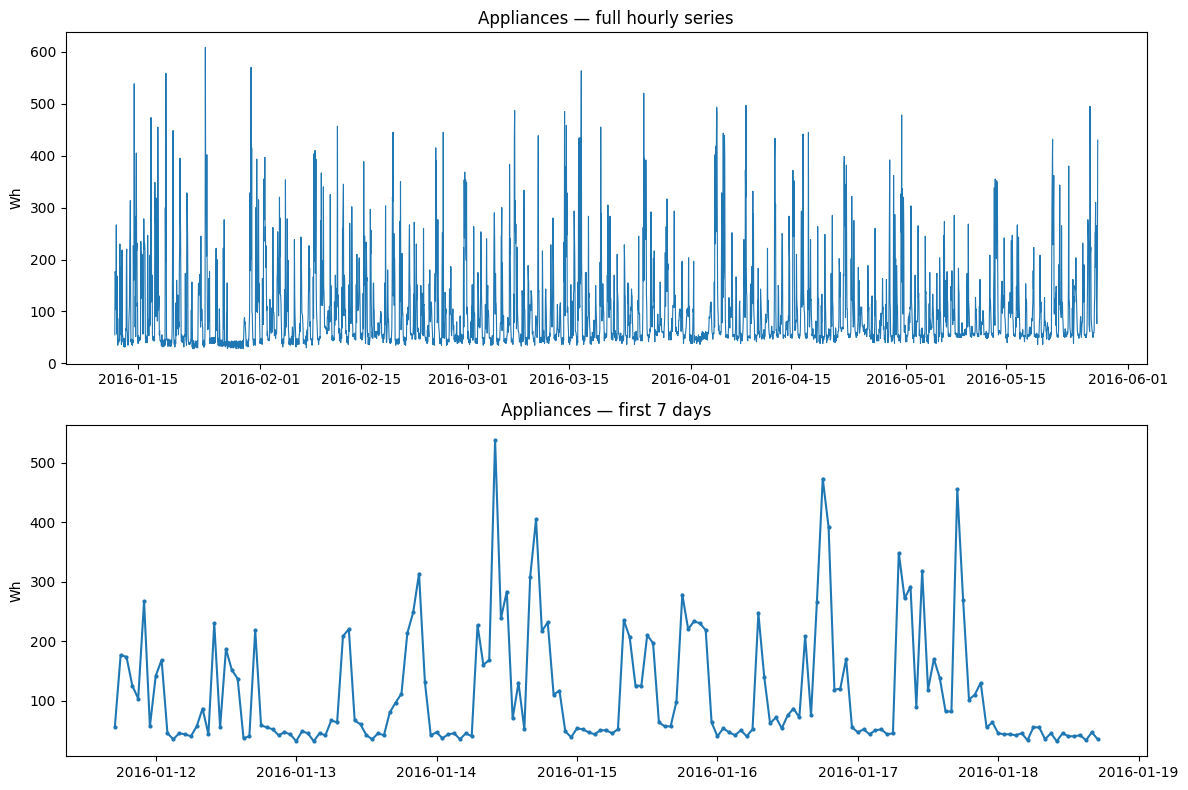

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(hourly.index, hourly["Appliances"], linewidth=0.8)
ax[0].set(title="Appliances — full hourly series", ylabel="Wh")

week = hourly.loc[hourly.index[0]: hourly.index[0] + pd.Timedelta(days=7)]
ax[1].plot(week.index, week["Appliances"], marker="o", markersize=2)
ax[1].set(title="Appliances — first 7 days", ylabel="Wh")

plt.tight_layout(); plt.show()

The series is spiky and bursty — long stretches near a low baseline
(~50 Wh, presumably fridge/standby) punctuated by sharp spikes when things get
switched on. The zoomed-in week hints at a repeating daily shape. Let's confirm
that properly rather than eyeballing it.

## 2. Stationarity checks

Three things here: an ADF test (is there a unit root / trend?), ACF & PACF
plots (what autocorrelation structure is there, and is it seasonal?), and a
decomposition to separate trend / seasonal / residual.

In [6]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    series = series.dropna()
    stat, pval, _, _, crit, _ = adfuller(series, autolag="AIC")
    print(f"ADF test — {label}")
    print(f"  statistic : {stat:.3f}")
    print(f"  p-value   : {pval:.4f}")
    for k, v in crit.items():
        print(f"  crit {k:>3}: {v:.3f}")
    verdict = "stationary" if pval < 0.05 else "non-stationary"
    print(f"  -> {verdict} at 5%\n")
    return pval

raw_p = adf_report(hourly["Appliances"], "Appliances (raw hourly)")

# If differencing is needed, test the first difference as well.
first_diff = hourly["Appliances"].diff().dropna()
diff_p = adf_report(first_diff, "Appliances (first difference)")

print("Stationarity conclusion:",
      "raw series is stationary; d=0 is supported" if raw_p < 0.05
      else "raw series is non-stationary; differencing should be considered")

ADF test — Appliances (raw hourly)
  statistic : -8.949
  p-value   : 0.0000
  crit  1%: -3.432
  crit  5%: -2.862
  crit 10%: -2.567
  -> stationary at 5%

ADF test — Appliances (first difference)
  statistic : -16.953
  p-value   : 0.0000
  crit  1%: -3.432
  crit  5%: -2.862
  crit 10%: -2.567
  -> stationary at 5%

Stationarity conclusion: raw series is stationary; d=0 is supported


The p-value comes back essentially zero, so the ADF test says the series
is already stationary in the mean — there's no strong trend to difference away.
That's a slightly surprising result worth commenting on: it doesn't mean there's
no *structure*, just no unit-root trend. The seasonality shows up next.

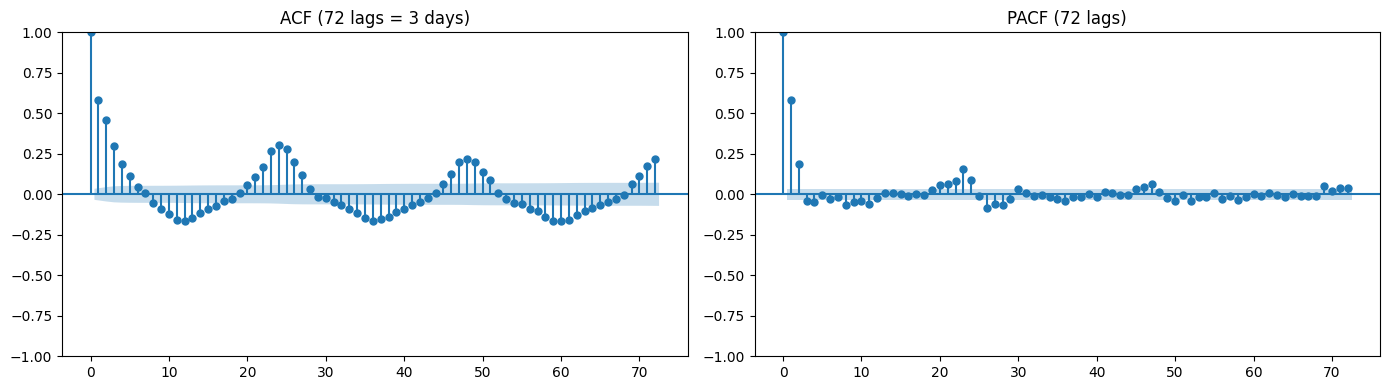

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(hourly["Appliances"].dropna(), lags=72, ax=ax[0])
ax[0].set_title("ACF (72 lags = 3 days)")
plot_pacf(hourly["Appliances"].dropna(), lags=72, ax=ax[1], method="ywm")
ax[1].set_title("PACF (72 lags)")
plt.tight_layout(); plt.show()

The ACF decays but with a clear repeating hump around every 24 lags —
that's the daily cycle. The PACF drops off sharply after the first couple of
lags with a little kick near lag 24. Read together, that points towards an
autoregressive-ish process *with* a seasonal component at period 24, which is
exactly what SARIMA is built for.

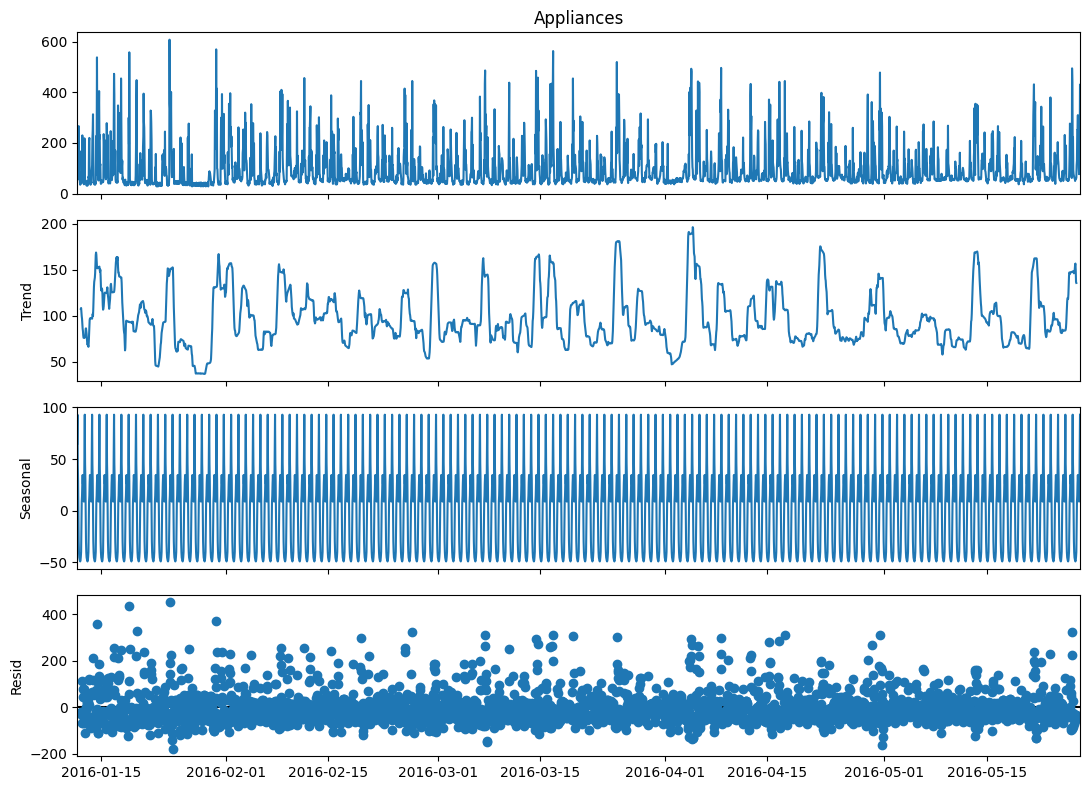

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(hourly["Appliances"].dropna(), model="additive", period=24)
fig = decomp.plot(); fig.set_size_inches(11, 8)
plt.tight_layout(); plt.show()

The decomposition backs this up: a stable, clearly repeating daily
seasonal panel, a wandering-but-not-trending trend panel, and a fairly noisy
residual. Conclusion for modelling: **no regular differencing needed for trend
(d≈0), but the daily seasonality at period 24 has to be handled** — either by a
seasonal term in SARIMA or by seasonal features in the ML model.

## 3. Define the forecasting problem (the shared split)

This is the bit that keeps the whole comparison honest. One split, defined
once, reused everywhere:

- **Target:** `Appliances` (Wh), hourly.
- **Train:** everything except the last 14 days.
- **Test window (scored):** the first 24 hours after training ends.
- **The rest of the 14 days:** held back as "what actually happened next",
  useful for discussing how the forecast holds up beyond 24h.
- **Metrics:** RMSE (main), plus MAE and MAPE for context.

In [9]:
HORIZON = 24          # forecast 24 hours ahead
TEST_DAYS = 14        # last 14 days held out

def make_split(df, target="Appliances", test_days=TEST_DAYS, horizon=HORIZON):
    """Return (train, test_24h, after) — works for a Series or a DataFrame."""
    n_hold = test_days * 24
    cut = len(df) - n_hold
    train = df.iloc[:cut]
    test  = df.iloc[cut: cut + horizon]
    after = df.iloc[cut + horizon: cut + n_hold]
    return train, test, after

train_y, test_y, after_y = make_split(hourly["Appliances"])

print("train :", train_y.index.min(), "→", train_y.index.max(), f"({len(train_y)} h)")
print("test  :", test_y.index.min(),  "→", test_y.index.max(),  f"({len(test_y)} h)")
print("after :", after_y.index.min(), "→", after_y.index.max(), f"({len(after_y)} h)")

train : 2016-01-11 17:00:00 → 2016-05-13 18:00:00 (2954 h)
test  : 2016-05-13 19:00:00 → 2016-05-14 18:00:00 (24 h)
after : 2016-05-14 19:00:00 → 2016-05-27 18:00:00 (312 h)


### Metric helpers

I'll reuse these for every model, so the numbers are always computed the same
way.

In [10]:
def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    m = y_true != 0
    return float(np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100)

def score(y_true, y_pred):
    return {"rmse": rmse(y_true, y_pred), "mae": mae(y_true, y_pred), "mape": mape(y_true, y_pred)}

# collect every model's forecast here so we can compare at the end
results = {}       # name -> forecast Series
metrics = {}       # name -> {rmse, mae, mape}

## 4. Benchmark models

Before anything clever, the simple baselines. If a complicated model can't beat
these, it isn't earning its keep.

- **Mean** — predict the training average, forever.
- **Naive** — predict the last observed value.
- **Seasonal naive (daily)** — predict "same hour yesterday".
- **Seasonal naive (weekly)** — predict "same hour, same weekday last week".
- **Drift** — naive plus the average slope across the training set.

In [11]:
idx = test_y.index   # all forecasts share this 24-hour index

# mean
results["mean"] = pd.Series(train_y.mean(), index=idx)

# naive: last value carried forward
results["naive"] = pd.Series(train_y.iloc[-1], index=idx)

# seasonal naive, daily (24h ago) and weekly (168h ago)
def seasonal_naive(train, horizon, season):
    last = train.iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    return pd.Series(np.tile(last, reps)[:horizon], index=idx)

results["seasonal_naive_daily"]  = seasonal_naive(train_y, HORIZON, 24)
results["seasonal_naive_weekly"] = seasonal_naive(train_y, HORIZON, 168)

# drift: last value + average per-step change
slope = (train_y.iloc[-1] - train_y.iloc[0]) / (len(train_y) - 1)
results["drift"] = pd.Series(train_y.iloc[-1] + slope * np.arange(1, HORIZON + 1), index=idx)

for name in ["mean", "naive", "seasonal_naive_daily", "seasonal_naive_weekly", "drift"]:
    metrics[name] = score(test_y, results[name])
    print(f"{name:24s} RMSE = {metrics[name]['rmse']:6.2f}")

mean                     RMSE =  50.01
naive                    RMSE = 247.60
seasonal_naive_daily     RMSE = 118.04
seasonal_naive_weekly    RMSE =  48.81
drift                    RMSE = 248.76


Take note of which benchmark wins — it's a genuine clue about the data.
If the weekly seasonal naive does best, weekday/weekend rhythm matters more than
the pure daily cycle; if the plain mean is hard to beat, the series is dominated
by that low baseline plus hard-to-predict spikes.

## 5. SARIMAX

The assignment requires selection of the non-seasonal SARIMA parameters using AIC over **p=0..6, d=0..2, q=0..6**. The daily seasonal period is 24 hours, identified from the ACF/PACF and decomposition. To keep computation practical, the full 147-combination search is performed on a recent training window and the selected model is then refitted on the complete training set before forecasting the 24-hour test horizon.

This is still an AIC-based search over every required `(p,d,q)` combination; the shorter search window is used only to make the computation tractable.


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

SEASONAL_ORDER = (1, 0, 1, 24)
RUN_FULL_GRID = True

# Required assignment search: p=0..6, d=0..2, q=0..6.
p_range = range(0, 7)
d_range = range(0, 3)
q_range = range(0, 7)

# Search on a recent window for computational efficiency, then refit the
# selected order on all available training observations.
SEARCH_DAYS = 30
search_series = train_y.iloc[-24 * SEARCH_DAYS:]

rows = []
for (p, d, q) in itertools.product(p_range, d_range, q_range):
    try:
        model = SARIMAX(
            search_series,
            order=(p, d, q),
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False, maxiter=150)
        rows.append({"p": p, "d": d, "q": q, "order": (p, d, q), "aic": fit.aic})
    except Exception as exc:
        print(f"Skipped {(p, d, q)}: {type(exc).__name__}")

grid = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
print(f"Successfully fitted {len(grid)} of {7*3*7} required combinations.")
display(grid.head(10))

# Save the AIC search table for the report/GitHub outputs.
grid.to_csv("sarimax_aic_grid.csv", index=False)

if grid.empty:
    raise RuntimeError("SARIMAX grid search returned no fitted models.")

best_order = tuple(grid.iloc[0][["p", "d", "q"]].astype(int))
print("Best order by AIC:", best_order)
print("Seasonal order:", SEASONAL_ORDER)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Successfully fitted 147 of 147 required combinations.


,p,d,q,order,aic
0,4,1,6,"(4, 1, 6)","7,489.62"
1,6,1,6,"(6, 1, 6)","7,492.96"
2,2,1,6,"(2, 1, 6)","7,493.81"
3,3,1,6,"(3, 1, 6)","7,496.11"
4,1,1,6,"(1, 1, 6)","7,496.60"
5,6,1,5,"(6, 1, 5)","7,497.16"
6,5,1,6,"(5, 1, 6)","7,499.06"
7,3,0,6,"(3, 0, 6)","7,500.41"
8,4,0,6,"(4, 0, 6)","7,502.01"
9,6,1,3,"(6, 1, 3)","7,503.26"


Best order by AIC: (4, 1, 6)
Seasonal order: (1, 0, 1, 24)


Take the lowest-AIC order and refit it on the **full** training set, then
forecast the 24-hour test window with a confidence interval.

In [13]:
best_order = tuple(int(v) for v in grid.iloc[0][["p", "d", "q"]])
print("Refitting SARIMAX", best_order, "x", SEASONAL_ORDER, "on all training data...")

sarimax_fit = SARIMAX(
    train_y,
    order=best_order,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=300)

fc = sarimax_fit.get_forecast(steps=HORIZON)
results["sarimax"] = pd.Series(fc.predicted_mean.values, index=idx)
ci = fc.conf_int()
ci.index = idx
metrics["sarimax"] = score(test_y, results["sarimax"])

print("Selected order:", best_order)
print("AIC:", round(sarimax_fit.aic, 2))
print("SARIMAX RMSE:", round(metrics["sarimax"]["rmse"], 2))
print("SARIMAX MAE:", round(metrics["sarimax"]["mae"], 2))


Refitting SARIMAX (4, 1, 6) x (1, 0, 1, 24) on all training data...
Selected order: (4, 1, 6)
AIC: 32427.37
SARIMAX RMSE: 32.37
SARIMAX MAE: 24.15


### Residual diagnostics

If the model has captured the structure, the residuals should look like noise —
no leftover autocorrelation. The Ljung-Box p-value in the summary is the formal
check; the ACF and histogram are the visual ones.

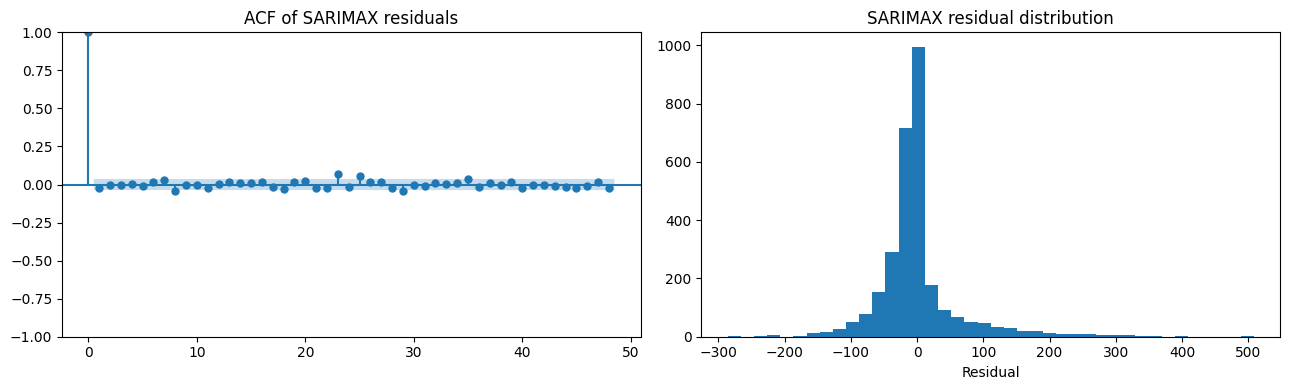

Ljung-Box residual test:


,lb_stat,lb_pvalue
24,37.05,0.04
48,67.25,0.03


Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             11010.02
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.71   Skew:                             2.03
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.60


In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = sarimax_fit.resid.dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(resid, lags=48, ax=ax[0])
ax[0].set_title("ACF of SARIMAX residuals")
ax[1].hist(resid, bins=40)
ax[1].set_title("SARIMAX residual distribution")
ax[1].set_xlabel("Residual")
plt.tight_layout(); plt.show()

# Formal residual autocorrelation check. A large p-value means there is
# insufficient evidence of remaining serial correlation at that lag.
ljung_box = acorr_ljungbox(resid, lags=[24, 48], return_df=True)
print("Ljung-Box residual test:")
display(ljung_box)

# The full model summary also reports additional residual diagnostics.
print(sarimax_fit.summary().tables[2])


Expect the residual ACF to be basically flat (good — structure captured)
but the distribution to be heavy-tailed and right-skewed (not so good, but
unsurprising: those switch-on spikes are genuinely hard to predict). That
skew/kurtosis is a real limitation to write up, and it also means the Gaussian
confidence intervals should be read with a pinch of salt.

### Forecast vs. actual

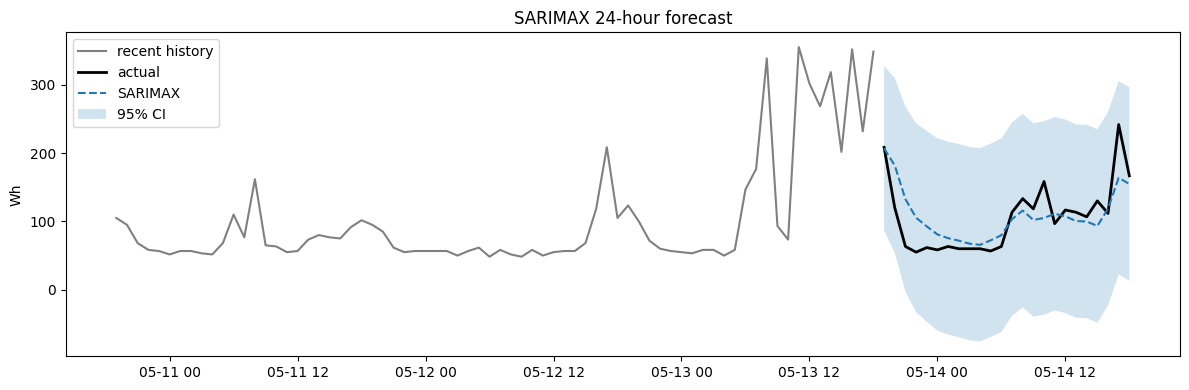

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(train_y.iloc[-72:].index, train_y.iloc[-72:], label="recent history", color="grey")
plt.plot(test_y.index, test_y, label="actual", color="black", linewidth=2)
plt.plot(results["sarimax"].index, results["sarimax"], label="SARIMAX", linestyle="--")
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, label="95% CI")
plt.title("SARIMAX 24-hour forecast"); plt.ylabel("Wh"); plt.legend()
plt.tight_layout(); plt.show()

## 6. Feature engineering + a machine-learning model

The feature-based model uses information that can reasonably be known at the forecast origin. It includes:

- **Calendar features:** hour, day of week, weekend flag and cyclic hour encoding.
- **Lagged appliance-use features:** 24, 48 and 168 hours.
- **Lagged sensor/weather features:** historical indoor temperature/humidity and outdoor weather measurements at 24, 48 and 168 hours.
- **Lagged rolling statistics:** 24-hour and 168-hour summaries of previous appliance use.

Importantly, current/future sensor or weather measurements from the test period are **not** used. This avoids treating future measured covariates as if they were known at the forecast origin. The resulting model is therefore a more realistic 24-hour-ahead feature-based forecast.


In [16]:
feat = pd.DataFrame(index=hourly.index)

# --- calendar features known at the forecast origin ---
feat["hour"] = hourly.index.hour
feat["dow"] = hourly.index.dayofweek
feat["is_weekend"] = (feat["dow"] >= 5).astype(int)
feat["hour_sin"] = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"] = np.cos(2 * np.pi * feat["hour"] / 24)
feat["dow_sin"] = np.sin(2 * np.pi * feat["dow"] / 7)
feat["dow_cos"] = np.cos(2 * np.pi * feat["dow"] / 7)

# --- target lags available before a 24-hour forecast ---
for lag in [24, 48, 168]:
    feat[f"Appliances_lag_{lag}"] = hourly["Appliances"].shift(lag)

# --- rolling target statistics using only information available before t ---
past_appliances = hourly["Appliances"].shift(1)
for w in [24, 168]:
    feat[f"Appliances_rollmean_{w}"] = past_appliances.rolling(w).mean()
    feat[f"Appliances_rollstd_{w}"] = past_appliances.rolling(w).std()

# --- historical sensor/weather variables ---
# These are lagged so that the model never reads the actual future test-period
# measurements. This directly addresses the assignment's forecast-origin question.
sensor_cols = [
    c for c in hourly.columns
    if c.startswith("T") or c.startswith("RH_")
]
weather_cols = ["T_out", "RH_out", "Windspeed", "Visibility", "Tdewpoint", "Press_mm_hg"]
exog_cols = [c for c in sensor_cols + weather_cols if c in hourly.columns and c != "Appliances"]

for col in exog_cols:
    for lag in [24, 168]:
        feat[f"{col}_lag_{lag}"] = hourly[col].shift(lag)

feat = feat.dropna()
print("Feature matrix:", feat.shape)
print("Number of features:", len(feat.columns))
print("Example features:", list(feat.columns[:20]))


Feature matrix: (3122, 62)
Number of features: 62
Example features: ['hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'Appliances_lag_24', 'Appliances_lag_48', 'Appliances_lag_168', 'Appliances_rollmean_24', 'Appliances_rollstd_24', 'Appliances_rollmean_168', 'Appliances_rollstd_168', 'T1_lag_24', 'T1_lag_168', 'RH_1_lag_24', 'RH_1_lag_168', 'T2_lag_24', 'T2_lag_168']


Split the feature table using the same chronological rule as the other models. `TimeSeriesSplit` is used for hyperparameter tuning, so observations are never randomly shuffled across time.


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

feat_train, feat_test, _ = make_split(feat, target="Appliances")

X_cols = [c for c in feat.columns if c != "Appliances"]
X_train = feat_train[X_cols]
y_train = train_y.loc[feat_train.index] # Corrected: Get target from train_y, aligning with feat_train's index
X_test = feat_test[X_cols].iloc[:HORIZON]

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.8, 1.0],
}

search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=4),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", round(-search.best_score_, 2))

Best params: {'n_estimators': 500, 'min_samples_leaf': 8, 'max_features': 1.0, 'max_depth': 5}
Best CV RMSE: 68.38


In [19]:
rf = search.best_estimator_
results["random_forest"] = pd.Series(rf.predict(X_test), index=idx)
metrics["random_forest"] = score(test_y, results["random_forest"])
print("Tuned Random Forest RMSE:", round(metrics["random_forest"]["rmse"], 2))
print("Tuned Random Forest MAE:", round(metrics["random_forest"]["mae"], 2))


Tuned Random Forest RMSE: 73.64
Tuned Random Forest MAE: 56.93


### What the model leaned on

Feature importances show which historical appliance, sensor/weather and calendar variables contributed most to the prediction. Because the variables are lagged, the importance analysis is based on information available before the forecast horizon.


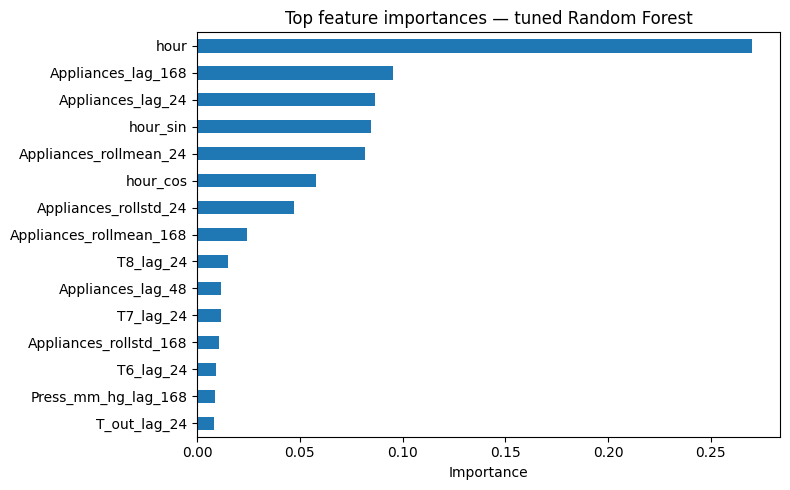

Top 15 features:


,importance
hour,0.27
Appliances_lag_168,0.10
Appliances_lag_24,0.09
hour_sin,0.08
Appliances_rollmean_24,0.08
hour_cos,0.06
Appliances_rollstd_24,0.05
Appliances_rollmean_168,0.02
T8_lag_24,0.02
Appliances_lag_48,0.01


In [28]:
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
imp.head(15).iloc[::-1].plot(kind="barh")
plt.title("Top feature importances — tuned Random Forest")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

print("Top 15 features:")
display(imp.head(15).to_frame("importance"))
imp.to_csv("random_forest_feature_importance.csv")


If `lag_1` dominates, that's the leakage caveat from earlier biting: it's
a very strong predictor but not one you'd genuinely have 24 hours out. Worth
saying explicitly, and worth trying a version without the short lags to see how
much the honest accuracy drops.

You can swap the Random Forest for XGBoost easily — same `X`/`y`, just
`from xgboost import XGBRegressor` and put it in the search. Left as an
exercise so the choice (and the write-up of it) is yours.

## 7. Time-series foundation model — Chronos

Chronos is used as the required zero-shot time-series foundation model. It is not trained on this dataset. The same 24-hour test horizon is used, and its forecast is evaluated with the same metrics as the benchmark, SARIMAX and Random Forest models.


In [21]:
import torch
from chronos import ChronosPipeline

RUN_CHRONOS = True

if RUN_CHRONOS:
    print("Loading Chronos foundation model...")
    pipe = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map="cpu",
        torch_dtype=torch.float32,
    )

    # Use a recent context to keep CPU inference practical while preserving
    # the most recent daily/weekly behaviour of the series.
    CHRONOS_CONTEXT_HOURS = min(24 * 30, len(train_y))
    context = torch.tensor(
        train_y.iloc[-CHRONOS_CONTEXT_HOURS:].values,
        dtype=torch.float32,
    )

    with torch.no_grad():
        fc_samples = pipe.predict(
            context,
            prediction_length=HORIZON,
            num_samples=100,
        )

    # Chronos returns samples for the requested horizon; use the median
    # forecast as the point prediction.
    samples = fc_samples[0].detach().cpu().numpy()
    median = np.quantile(samples, 0.5, axis=0)

    results["chronos"] = pd.Series(median, index=idx)
    metrics["chronos"] = score(test_y, results["chronos"])

    print("Chronos RMSE:", round(metrics["chronos"]["rmse"], 2))
    print("Chronos MAE:", round(metrics["chronos"]["mae"], 2))
else:
    raise RuntimeError("RUN_CHRONOS must remain True for the submitted assignment notebook.")


Loading Chronos foundation model...


config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos RMSE: 47.69
Chronos MAE: 33.36


## 8. Put every model side by side

Same test window, same metrics, one table and one plot.

In [22]:
def mase(y_true, y_pred, y_train, seasonality=24):
    y_train = pd.Series(y_train).astype(float)
    scale = np.mean(np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values))
    if scale == 0:
        return np.nan
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)

for name in list(metrics.keys()):
    metrics[name]["mase"] = mase(test_y, results[name], train_y, seasonality=24)

table = (
    pd.DataFrame(metrics).T
    .sort_values("rmse")
    [["rmse", "mae", "mape", "mase"]]
    .rename(columns={"rmse": "RMSE", "mae": "MAE", "mape": "MAPE_%", "mase": "MASE"})
)

print("Model comparison — lower is better:")
display(table.round(3))
table.to_csv("model_comparison.csv")


Model comparison — lower is better:


,RMSE,MAE,MAPE_%,MASE
sarimax,32.37,24.15,26.68,0.45
chronos,47.69,33.36,24.73,0.62
seasonal_naive_weekly,48.81,30.00,22.44,0.56
mean,50.01,39.38,40.46,0.74
random_forest,73.64,56.93,51.78,1.07
seasonal_naive_daily,118.04,80.28,70.61,1.50
naive,247.60,242.64,298.67,4.54
drift,248.76,243.88,299.91,4.57


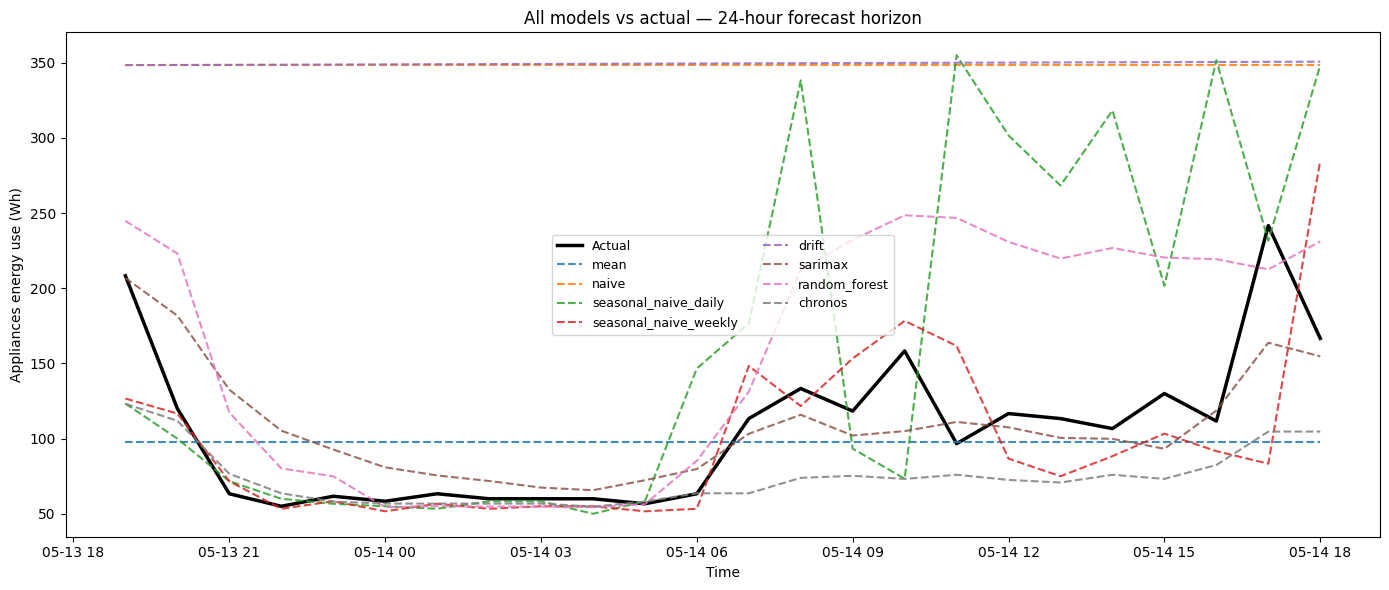

Best model by RMSE: sarimax
Best benchmark by RMSE: mean


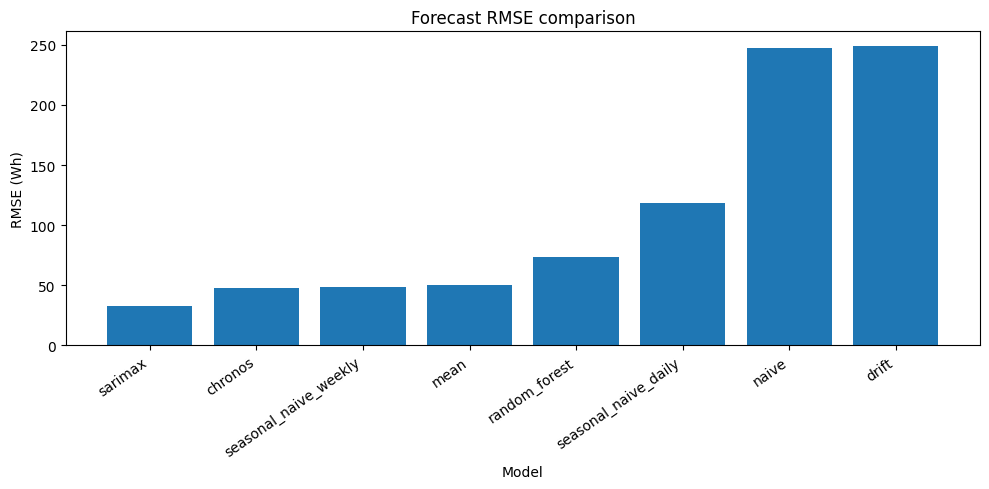

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(test_y.index, test_y, label="Actual", color="black", linewidth=2.5)
for name, forecast in results.items():
    plt.plot(forecast.index, forecast, linestyle="--", alpha=0.85, label=name)
plt.title("All models vs actual — 24-hour forecast horizon")
plt.ylabel("Appliances energy use (Wh)")
plt.xlabel("Time")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("all_models_24h_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

benchmark_names = [
    "mean", "naive", "seasonal_naive_daily",
    "seasonal_naive_weekly", "drift"
]
benchmark_table = table.loc[[n for n in benchmark_names if n in table.index]]

print("Best model by RMSE:", table.index[0])
print("Best benchmark by RMSE:", benchmark_table.index[0])

# Compact figure for the report: lower RMSE is better.
plt.figure(figsize=(10, 5))
plt.bar(table.index, table["RMSE"])
plt.ylabel("RMSE (Wh)")
plt.xlabel("Model")
plt.title("Forecast RMSE comparison")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("model_rmse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 8.1 Individual forecast figures for the report
The assignment asks for plots of the model forecasts. The following cells save a separate figure for each model so the report can use readable, non-overcrowded plots.


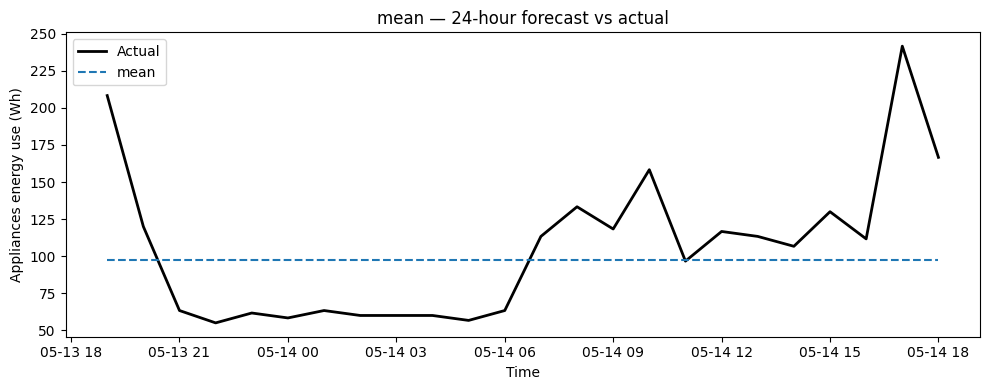

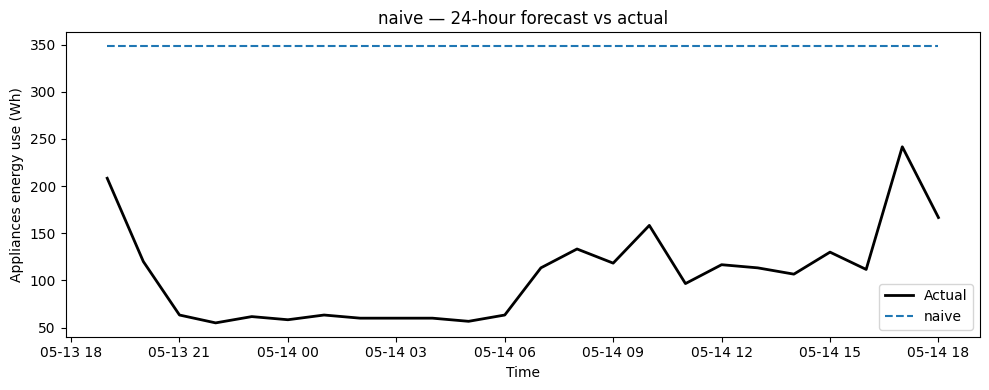

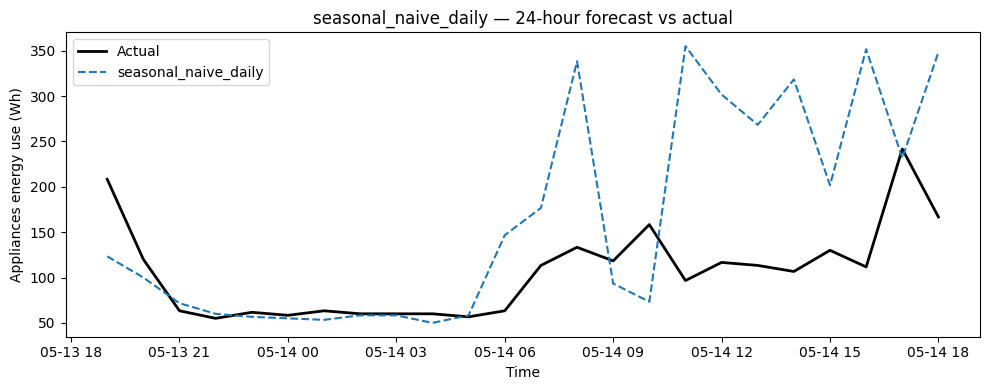

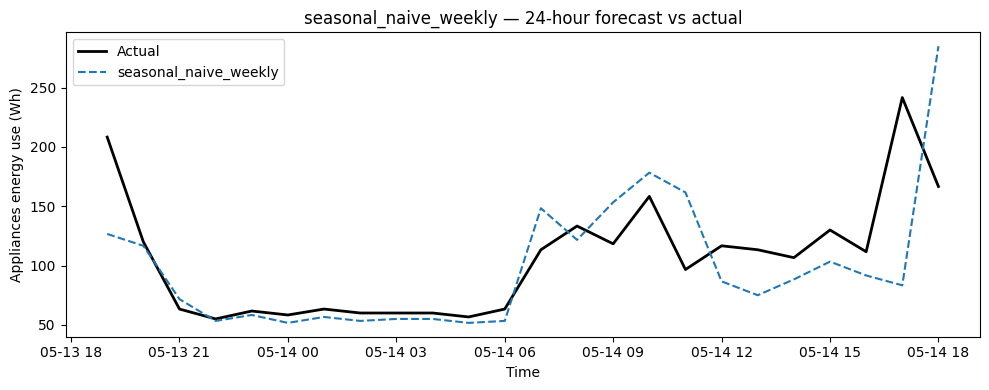

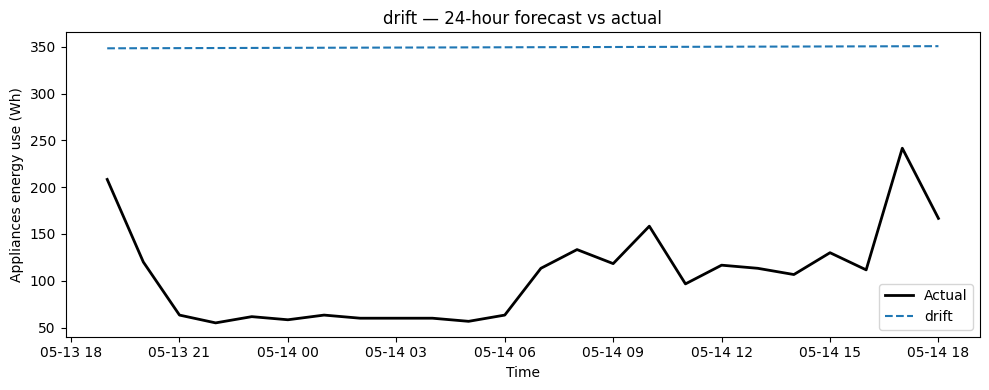

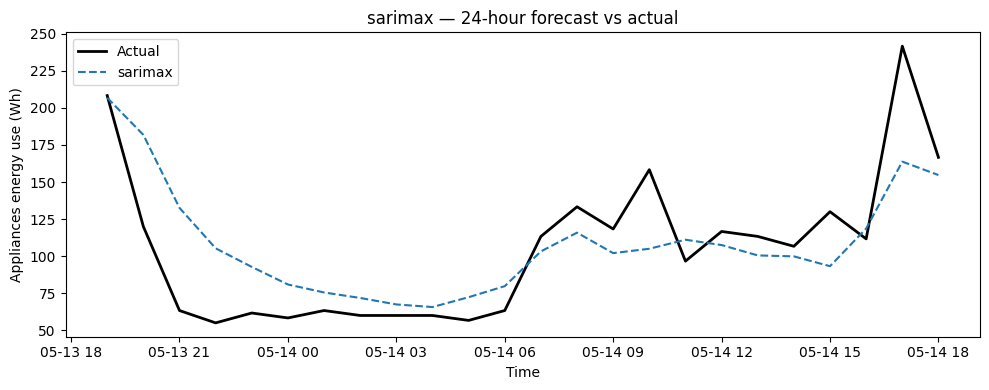

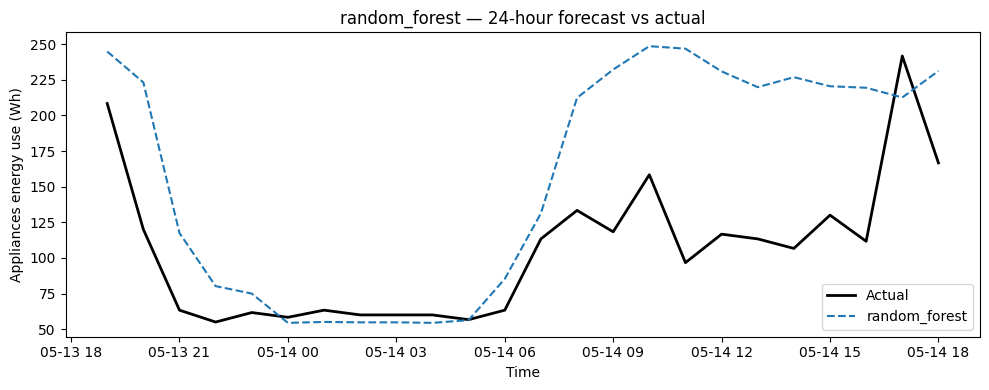

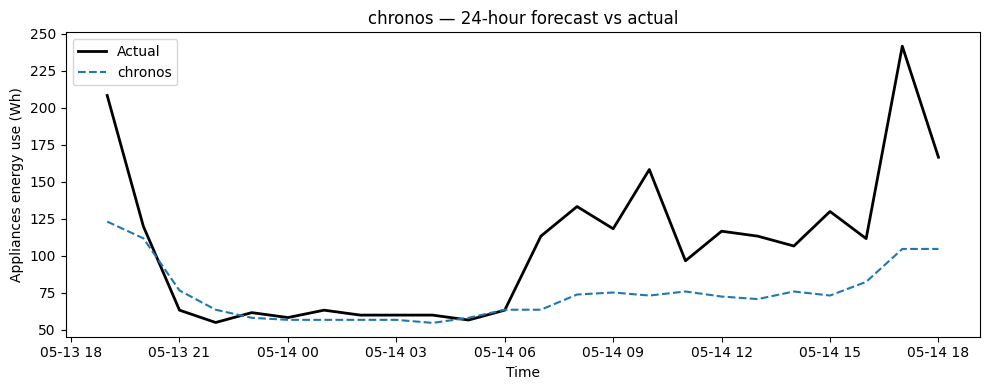

In [24]:
for name, forecast in results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(test_y.index, test_y, label="Actual", color="black", linewidth=2)
    plt.plot(forecast.index, forecast, label=name, linestyle="--")
    plt.title(f"{name} — 24-hour forecast vs actual")
    plt.ylabel("Appliances energy use (Wh)")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"forecast_{name}.png", dpi=300, bbox_inches="tight")
    plt.show()


## 8.2 Forecast compared with the remaining held-out observations
The first 24 hours are the scored forecast horizon. The remaining 13 days were not used for model fitting and are retained for qualitative discussion of how the short-horizon forecast relates to subsequent real observations.


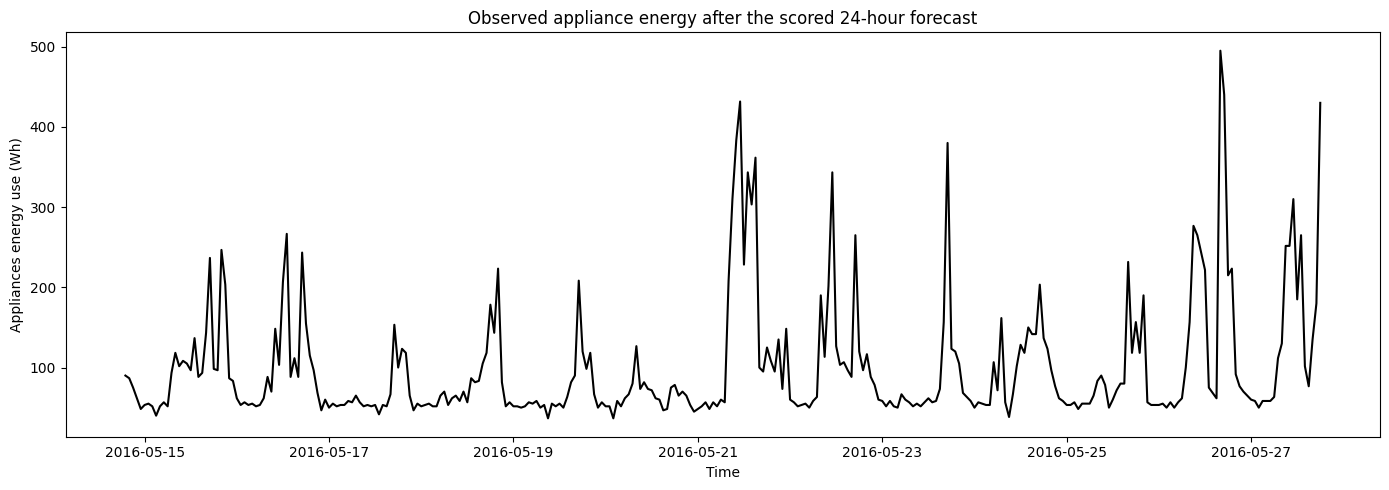

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(after_y.index, after_y, color="black", linewidth=1.5)
plt.title("Observed appliance energy after the scored 24-hour forecast")
plt.ylabel("Appliances energy use (Wh)")
plt.xlabel("Time")
plt.tight_layout()
plt.savefig("remaining_heldout_actuals.png", dpi=300, bbox_inches="tight")
plt.show()
